In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = 'course_lead_scoring.csv'

In [3]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [4]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [6]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val =df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [7]:
for col in numerical:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    print(f'{col}: {auc:.4f}')

number_of_courses_viewed: 0.7636
annual_income: 0.5520
interaction_count: 0.7383
lead_score: 0.6145


In [8]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_pred)

round(val_auc, 3)

0.92

In [9]:
scores = []
thresholds = np.linspace(0, 1, 101)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

for t in thresholds:    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
    
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    diff = abs(precision - recall)

    scores.append((t, tp, fp, tn, fn, recall, precision, diff))

In [10]:
df_scores = pd.DataFrame(scores, columns=['threshold', 'true_positive', 'false_positive', 'true_negative', 'false_negative', 'recall', 'precision', 'diff'])

df_scores[::10]

,threshold,true_positive,false_positive,true_negative,false_negative,recall,precision,diff
0,0.0,171,122,0,0,1.000000,0.583618,0.416382
10,0.1,168,93,29,3,0.982456,0.643678,0.338778
20,0.2,165,68,54,6,0.964912,0.708155,0.256758
30,0.3,164,50,72,7,0.959064,0.766355,0.192709
40,0.4,157,31,91,14,0.918129,0.835106,0.083022
50,0.5,153,25,97,18,0.894737,0.859551,0.035186
60,0.6,143,16,106,28,0.836257,0.899371,0.063114
70,0.7,135,11,111,36,0.789474,0.924658,0.135184
80,0.8,124,7,115,47,0.725146,0.946565,0.221419
90,0.9,99,6,116,72,0.578947,0.942857,0.363910


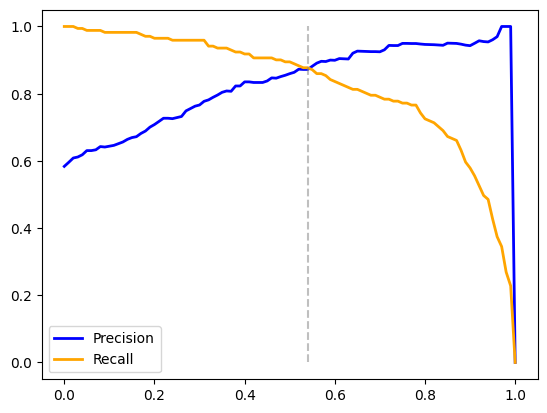

In [41]:
plt.plot(df_scores.threshold, df_scores.precision, label='Precision', color='blue', linewidth=2)
plt.plot(df_scores.threshold, df_scores.recall, label='Recall', color='orange', linewidth=2)

plt.vlines(0.54, ymin=0, ymax=1, color='grey', linestyle='--', alpha=0.5)

plt.legend()

We see that these two curves intersect approximately at t = 0.52. let's double check that in our dataframe.

In [12]:
df_scores[(df_scores.threshold > 0.5) & (df_scores.threshold < 0.6)]

,threshold,true_positive,false_positive,true_negative,false_negative,recall,precision,diff
51,0.51,152,24,98,19,0.888889,0.863636,0.025253
52,0.52,151,22,100,20,0.883041,0.872832,0.010209
53,0.53,150,22,100,21,0.877193,0.872093,0.005100
54,0.54,150,22,100,21,0.877193,0.872093,0.005100
55,0.55,149,20,102,22,0.871345,0.881657,0.010312
56,0.56,147,18,104,24,0.859649,0.890909,0.031260
57,0.57,147,17,105,24,0.859649,0.896341,0.036692
58,0.58,146,17,105,25,0.853801,0.895706,0.041904
59,0.59,144,16,106,27,0.842105,0.900000,0.057895


We see that at t = 0.53 & t = 0.54 we have the lowest difference between precision and recall.

In [13]:
df_scores['f1_score'] = (2 * df_scores.precision * df_scores.recall / (df_scores.precision + df_scores.recall))

df_scores[df_scores.f1_score == max(df_scores.f1_score)]

,threshold,true_positive,false_positive,true_negative,false_negative,recall,precision,diff,f1_score
52,0.52,151,22,100,20,0.883041,0.872832,0.010209,0.877907


In [45]:
df_scores.loc[df_scores.f1_score.argmax()]

threshold           0.520000
true_positive     151.000000
false_positive     22.000000
true_negative     100.000000
false_negative     20.000000
recall              0.883041
precision           0.872832
diff                0.010209
f1_score            0.877907
Name: 52, dtype: float64

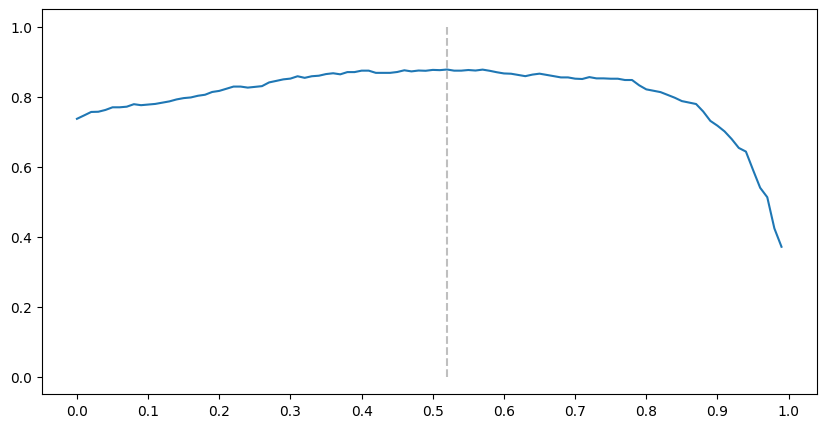

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(df_scores.threshold, df_scores.f1_score)
plt.vlines(0.52, 0, 1, linestyle='--', color='grey', alpha=0.5)
plt.xticks(np.linspace(0, 1, 11))

plt.show()

In [19]:
kfold = KFold(n_splits = 5, random_state = 1, shuffle=True)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    train_dicts = df_train[categorical + numerical].to_dict(orient='records')
    val_dicts = df_val[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=10000)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_pred)

    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.822 +- 0.036


In [49]:
for C in [0.000001, 0.001, 1]:
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
    
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
        train_dicts = df_train[categorical + numerical].to_dict(orient='records')
        val_dicts = df_val[categorical + numerical].to_dict(orient='records')
    
        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(train_dicts)
        X_val = dv.transform(val_dicts)
    
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)
    
        y_pred = model.predict_proba(X_val)[:, 1]
    
        auc = roc_auc_score(y_val, y_pred)
    
        scores.append(auc)
    
    print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.560 +- 0.024
0.867 +- 0.029
0.822 +- 0.036
